# Biomarcador 1 - Latencia de Arranque

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from routines import rellenar_muestras

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250507_132315.parquet")


## Rutinas

In [ ]:
from numpy import array, ndarray, sqrt
from scipy.signal import convolve


df = df.rename(columns={"timestamp": "ts", "stimuli_x": "sx", "stimuli_y": "sy", "eyes_x": "ex", "eyes_y": "ey"})


def distance(x, y):
    """
    Calcula la distancia entre dos puntos en un espacio 2D (vector desplazamiento).

    Args:
        x (ndarray): Coordenadas x de los puntos.
        y (ndarray): Coordenadas y de los puntos.

    Returns:
        ndarray: Distancia entre los puntos.
    """
    x_prev = x[:-1]
    x_curr = x[1:]
    y_prev = y[:-1]
    y_curr = y[1:]
    return sqrt((x_prev - x_curr) ** 2 + (y_prev - y_curr) ** 2)


def differentiate(channel):
    window = array([300, -294, -532, -503, -296, 0, 296, 503, 532, 294, -300])
    result = convolve(channel, window, "same") / 5148.0
    result[:5] = 0
    result[-5:] = 0
    return result * 1000




TypeError: find_peaks() got an unexpected keyword argument 'height'

In [17]:
rellenado = rellenar_muestras(df)

distance_e = distance(rellenado["ex"], rellenado["ey"])

time = rellenado["ts"][1:-1]
distance_e = distance_e.values[1:-1]


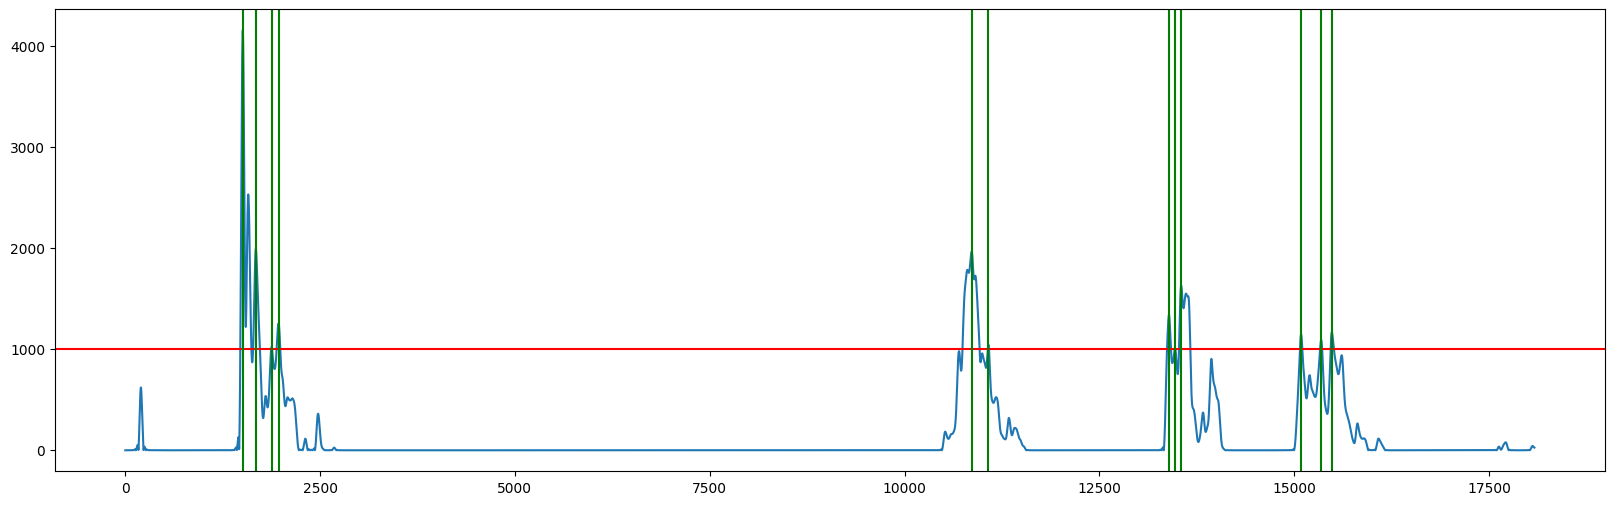

In [ ]:
from scipy import signal
from typing import Iterator

def denoise_35(channel: np.ndarray) -> np.ndarray:
    """Remove high frequency noise from the channel

    Args:
        channel (ndarray): Channel

    Returns:
        ndarray: Channel
    """
    # Hacemos un filtrado agresivo ya que lo que nos interesa es la forma de onda
    # en general de la señal para identificar el desfase
    b, a = signal.butter(3, 0.035)
    y = signal.filtfilt(b, a, channel)
    return y

def find_peaks(vel: np.ndarray, threshold: float) -> Iterator[int]:
    max_idx = None
    max_value = None
    for idx, sample in enumerate(vel):
        if sample < threshold:
            if max_idx is not None:
                yield max_idx
                
            max_idx = None
            max_value = None
            continue

        if max_idx is None or sample > max_value:
            max_idx = idx
            max_value = sample

    if max_idx is not None:
        yield max_idx



from scipy.signal import medfilt
THRESHOLD = 1000
START = 100
END = rellenado.shape[0]

eyes_x = rellenado["ex"].values.astype(np.int32)
eyes_y = rellenado["ey"].values.astype(np.int32)

dis = distance(eyes_x, eyes_y)[1:-1]
vel = abs(differentiate(dis))
# vel = medfilt(vel, 31)
vel = abs(denoise_35(vel))
peaks = list(find_peaks(vel, threshold=THRESHOLD))

plt.plot(vel[START:END])
plt.axhline(THRESHOLD, color="r")
for peak in peaks:
    p = peak - START
    if p < 0 or p > END:
        continue
    plt.axvline(p, color='g')
    


In [14]:
rellenado[40:60]

,ts,sx,sy,stimuli_color,ex,ey,key
40,1746616977426,0,0,16777215,1011,443,0
41,1746616977427,0,0,16777215,1011,443,0
42,1746616977428,0,0,16777215,1011,443,0
43,1746616977429,0,0,16777215,1011,443,0
44,1746616977430,0,0,16777215,1011,443,0
45,1746616977431,0,0,16777215,1011,443,0
46,1746616977432,0,0,16777215,1011,443,0
47,1746616977433,0,0,16777215,1011,443,0
48,1746616977434,0,0,16777215,1011,443,0
49,1746616977435,0,0,16777215,1011,443,0
